# 00b — EDA: connectivity & infrastructure inputs

**What this notebook does.** A read-only tour of every *infrastructure-side* input before
the pipeline (notebooks 03–05) uses it: the ACMA licence register, the NBN footprint
shapefiles, the Mobile Black Spot Program KMLs, the NT mobile coverage guide, and the RICT
community-phone list. It confirms units, code meanings and schemas by inspection (not
assumption), quantifies the "proximity but no tower" contradiction, and ends with a
data-quality list for notebooks 03–06.

**What it reads** (raw / external only):

| dataframe | file(s) | what it is |
|---|---|---|
| `acma_sites_df` | `external/acma_rrl/site.csv` | 129k licensed sites nationally; 3,771 in the NT |
| `acma_licences_df` | `external/acma_rrl/licence.csv` | one row per licence (3 cols read) |
| `acma_clients_df` | `external/acma_rrl/client.csv` | licensee names (2 cols read) |
| `acma_devices_nt_df` | `external/acma_rrl/device_details.csv` | **NT sites only**, read in chunks — never the full 2.15M rows |
| `nbn_fixedline_gdf` / `nbn_wireless_gdf` | `external/nbn/.../*.shp` | NBN technology footprint polygons, NT bbox |
| `mbsp_placemarks_df` | `external/mbsp/MBSP - Round *.kml` (8) | Mobile Black Spot Program funded sites |
| `coverage_guide_raw_df` | `raw/nt_mobile_coverage/mobile-coverage-all-sites.xlsx` | NT coverage guide ("a GUIDE only") |
| `rict_communities_df` | `raw/rict/Com_RICT_Community_NIAA_2024.json` | RICT community phones / Wi-Fi phones |

**What it writes.** Nothing except PNG plots to `docs/eda/`.

**STAND is not read here or anywhere** — it was dropped from the pipeline (no unique signal).

Section E dumps every RICT property key and `site_type` value; the decision it was waiting
on is now recorded there (all 4 codes = public access; nb 06 matches within `RICT_MATCH_KM`).

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import json
import glob
import xml.etree.ElementTree as ET
import os
from pathlib import Path

# notebooks/ -> repo root, so the data/ paths below resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
# Every raw/external file the notebook needs is read here. Two of them need preprocessing
# to be read at all (chunked NT filter on device_details; header-row hunt on the xlsx is
# done in the next cell) — the raw read still happens here.

ACMA_DIR   = "data/external/acma_rrl"
SITE_CSV   = f"{ACMA_DIR}/site.csv"
LICENCE_CSV = f"{ACMA_DIR}/licence.csv"
CLIENT_CSV  = f"{ACMA_DIR}/client.csv"
DEVICE_CSV  = f"{ACMA_DIR}/device_details.csv"
NBN_FIXEDLINE_SHP = "data/external/nbn/fixedline/nbn_coverage_fixedline.shp"
NBN_WIRELESS_SHP  = "data/external/nbn/wireless/nbn_coverage_wireless.shp"
MBSP_GLOB   = "data/external/mbsp/MBSP - Round *.kml"
COVERAGE_GUIDE_XLSX = "data/raw/nt_mobile_coverage/mobile-coverage-all-sites.xlsx"
RICT_JSON   = "data/raw/rict/Com_RICT_Community_NIAA_2024.json"

# rough NT bounding box (lon_min, lat_min, lon_max, lat_max) — the NBN shapefiles are
# national and huge, so GDAL reads only this window
NT_BBOX = (128.9, -26.3, 138.1, -10.8)
KML_NS  = {"k": "http://www.opengis.net/kml/2.2"}

# --- ACMA: site / licence / client are small enough to read whole ---
acma_sites_df    = pd.read_csv(SITE_CSV, dtype=str)
acma_licences_df = pd.read_csv(LICENCE_CSV, dtype=str,
                               usecols=["LICENCE_NO", "CLIENT_NO", "LICENCE_CATEGORY_NAME"])
acma_clients_df  = pd.read_csv(CLIENT_CSV, dtype=str, usecols=["CLIENT_NO", "LICENCEE"])

# --- ACMA device_details: 2.15M rows. Get the NT site-id set first, then keep only NT
#     rows as we stream the file in chunks. usecols keeps it to the columns we explore. ---
_nt_site_ids = set(acma_sites_df.loc[acma_sites_df["STATE"] == "NT", "SITE_ID"])
_device_cols = ["SITE_ID", "LICENCE_NO", "DEVICE_TYPE", "FREQUENCY", "BANDWIDTH",
                "EIRP", "EIRP_UNIT", "TRANSMITTER_POWER", "TRANSMITTER_POWER_UNIT",
                "HEIGHT", "EMISSION", "POLARISATION"]
_chunks = []
for _chunk in pd.read_csv(DEVICE_CSV, dtype=str, usecols=_device_cols, chunksize=200_000):
    _chunks.append(_chunk[_chunk["SITE_ID"].isin(_nt_site_ids)])
acma_devices_nt_df = pd.concat(_chunks, ignore_index=True)

# --- NBN footprints, NT window only ---
nbn_fixedline_gdf = gpd.read_file(NBN_FIXEDLINE_SHP, bbox=NT_BBOX)
nbn_wireless_gdf  = gpd.read_file(NBN_WIRELESS_SHP,  bbox=NT_BBOX)

# --- MBSP: parse every placemark from every round into one raw frame (round tagged,
#     nothing deduped or renamed yet) ---
_mbsp_rows = []
for _path in sorted(glob.glob(MBSP_GLOB)):
    _round = _path.split(" - ")[1].replace(" Funded Base Stations.kml", "")
    for _pm in ET.parse(_path).findall(".//k:Placemark", KML_NS):
        _f = {sd.get("name"): sd.text for sd in _pm.findall(".//k:SimpleData", KML_NS)}
        _coord = _pm.find(".//k:coordinates", KML_NS)
        if _coord is not None and _coord.text:
            _lon, _lat = _coord.text.strip().split()[0].split(",")[:2]
            _f["_lon"], _f["_lat"] = float(_lon), float(_lat)
        _f["_round"] = _round
        _mbsp_rows.append(_f)
mbsp_placemarks_df = pd.DataFrame(_mbsp_rows)

# --- coverage guide: raw, no header (row 0 is a banner); header row found in next cell ---
coverage_guide_raw_df = pd.read_excel(COVERAGE_GUIDE_XLSX, header=None)

# --- RICT: FeatureCollection of points; take properties into a frame ---
with open(RICT_JSON, encoding="utf-8") as fh:
    _rict = json.load(fh)
rict_communities_df = pd.DataFrame([f["properties"] for f in _rict["features"]])

EDA_PLOT_DIR = Path("docs/eda")
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print("rows read:")
print(f"  acma_sites_df          : {len(acma_sites_df):>7}  (NT: {len(_nt_site_ids)})")
print(f"  acma_licences_df       : {len(acma_licences_df):>7}")
print(f"  acma_clients_df        : {len(acma_clients_df):>7}")
print(f"  acma_devices_nt_df     : {len(acma_devices_nt_df):>7}  (NT sites only, chunked)")
print(f"  nbn_fixedline_gdf      : {len(nbn_fixedline_gdf):>7}  (NT bbox)")
print(f"  nbn_wireless_gdf       : {len(nbn_wireless_gdf):>7}  (NT bbox)")
print(f"  mbsp_placemarks_df     : {len(mbsp_placemarks_df):>7}  (all rounds, all states, pre-dedupe)")
print(f"  coverage_guide_raw_df  : {len(coverage_guide_raw_df):>7}  (raw, header not yet applied)")
print(f"  rict_communities_df    : {len(rict_communities_df):>7}  (all states)")

rows read:
  acma_sites_df          :  129492  (NT: 3771)
  acma_licences_df       :  164205
  acma_clients_df        :   14332
  acma_devices_nt_df     :   26767  (NT sites only, chunked)
  nbn_fixedline_gdf      :      35  (NT bbox)
  nbn_wireless_gdf       :     348  (NT bbox)
  mbsp_placemarks_df     :    2710  (all rounds, all states, pre-dedupe)
  coverage_guide_raw_df  :     193  (raw, header not yet applied)
  rict_communities_df    :     535  (all states)


---
## A. ACMA Register of Radiocommunications Licences

The register is the closest thing to a full carrier-tower inventory, but it is a
*licence* register: a row is permission to transmit, not proof a site is on air, and most
carrier-held licences are point-to-point microwave backhaul, not mobile-phone spectrum.
This section pins down the codes and units notebook 03 needs.

### A.1 NT sites — count, coordinate precision

In [3]:
acma_sites_nt_df = acma_sites_df[acma_sites_df["STATE"] == "NT"].copy()
acma_sites_nt_df["lat"] = pd.to_numeric(acma_sites_nt_df["LATITUDE"], errors="coerce")
acma_sites_nt_df["lon"] = pd.to_numeric(acma_sites_nt_df["LONGITUDE"], errors="coerce")

print(f"NT sites: {len(acma_sites_nt_df)}  |  with a usable coordinate: "
      f"{acma_sites_nt_df[['lat','lon']].dropna().shape[0]}")
print("\nSITE_PRECISION (how well the coordinate is known):")
print(acma_sites_nt_df["SITE_PRECISION"].value_counts(dropna=False))
print("\n-> ~40% are 'Unknown' or 'Within 100 metres'. Fine for straight-line triage, not "
      "for anything finer.")

NT sites: 3771  |  with a usable coordinate: 3771

SITE_PRECISION (how well the coordinate is known):
SITE_PRECISION
Within 10 metres     1838
Unknown              1452
Within 100 metres     480
NaN                     1
Name: count, dtype: int64

-> ~40% are 'Unknown' or 'Within 100 metres'. Fine for straight-line triage, not for anything finer.


### A.2 Link device → licence → licensee, and see what licence categories carriers hold

`device_details.LICENCE_NO → licence.LICENCE_NO`, `licence.CLIENT_NO → client.CLIENT_NO`.
A licensee is treated as a mobile carrier if its name contains one of the known operator
strings.

In [4]:
# operator name fragments that mark a mobile network operator in client.LICENCEE
ACMA_CARRIER_PATTERNS = ("TELSTRA", "OPTUS", "VODAFONE", "TPG", "HUTCHISON", "PIVOTEL", "DENSE AIR")

def carrier_of(licensee: str):
    text = (licensee or "").upper()
    return next((p for p in ACMA_CARRIER_PATTERNS if p in text), None)

licence_client_df = acma_licences_df.merge(acma_clients_df, on="CLIENT_NO", how="left")
licence_client_df["carrier"] = licence_client_df["LICENCEE"].map(carrier_of)

carrier_licences_df = licence_client_df[licence_client_df["carrier"].notna()]
print(f"carrier-held licences (all AU): {len(carrier_licences_df)}")
print("\nLICENCE_CATEGORY_NAME for carrier-held licences (top 15):")
print(carrier_licences_df["LICENCE_CATEGORY_NAME"].value_counts().head(15))
print("\n-> 'Point to Point' etc. dominate; the mobile-band categories (700 MHz Band, "
      "1800 MHz Band, 850/900 MHz Band, PMTS Class B, ...) are a minority of licences.")

carrier-held licences (all AU): 17472

LICENCE_CATEGORY_NAME for carrier-held licences (top 15):
LICENCE_CATEGORY_NAME
Point to Point                          13967
Land Mobile System - > 30MHz              929
Point to Multipoint                       882
Subscription Television Broadcasting      729
PMTS Class B                              302
Earth Receive                             228
Fixed Earth                               214
Point to Point (Self Coordinated)          76
Ambulatory System                          17
Space                                      17
PMTS Class B (870-890 MHz)                 13
Aeronautical Assigned System               12
3.4 GHz Band                               11
1800 MHz Band                              10
Space Receive                               9
Name: count, dtype: int64

-> 'Point to Point' etc. dominate; the mobile-band categories (700 MHz Band, 1800 MHz Band, 850/900 MHz Band, PMTS Class B, ...) are a minority of licences.


### A.3 `DEVICE_TYPE` — inspect the codes, don't assume

The DDL just says "device type code (transmitter/receiver/etc.)". Check what actually
appears for NT sites.

In [5]:
print("DEVICE_TYPE values on NT sites:")
print(acma_devices_nt_df["DEVICE_TYPE"].value_counts(dropna=False))
print("\n-> only 'T' and 'R'. Read as Transmitter / Receiver. Notebook 03 keeps DEVICE_TYPE == 'T' "
      "so a receive-only antenna at a site never counts as a transmitter.")

DEVICE_TYPE values on NT sites:
DEVICE_TYPE
T    13748
R    13019
Name: count, dtype: int64

-> only 'T' and 'R'. Read as Transmitter / Receiver. Notebook 03 keeps DEVICE_TYPE == 'T' so a receive-only antenna at a site never counts as a transmitter.


### A.4 `FREQUENCY` and `BANDWIDTH` — what unit?

Notebook 03 filters transmitters to handset bands by frequency and sums `BANDWIDTH` for a
capacity indicator, so the unit has to be certain.

FREQUENCY: min 2.33e+05  median 1.44e+09  max 8.54e+10


  -> values are ~1e8–1e10, i.e. plain Hz. '700 MHz' == 700_000_000.


BANDWIDTH: min 100  median 1e+07  max 5e+09
  -> also Hz (median 1e7 == 10 MHz channel). spectrum_depth_khz = sum(BANDWIDTH)/1000.
EIRP_UNIT: {'W': 26767} | TRANSMITTER_POWER_UNIT: {'W': 26767} -> watts


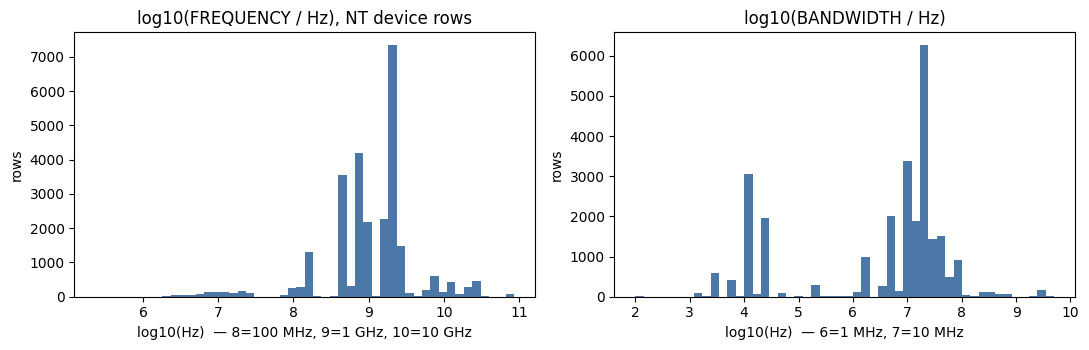

In [6]:
freq_hz = pd.to_numeric(acma_devices_nt_df["FREQUENCY"], errors="coerce")
bw_hz   = pd.to_numeric(acma_devices_nt_df["BANDWIDTH"], errors="coerce")

print("FREQUENCY: min {:.3g}  median {:.3g}  max {:.3g}".format(freq_hz.min(), freq_hz.median(), freq_hz.max()))
print("  -> values are ~1e8–1e10, i.e. plain Hz. '700 MHz' == 700_000_000.")
print("BANDWIDTH: min {:.3g}  median {:.3g}  max {:.3g}".format(bw_hz.min(), bw_hz.median(), bw_hz.max()))
print("  -> also Hz (median 1e7 == 10 MHz channel). spectrum_depth_khz = sum(BANDWIDTH)/1000.")
print("EIRP_UNIT:", acma_devices_nt_df["EIRP_UNIT"].value_counts(dropna=False).to_dict(),
      "| TRANSMITTER_POWER_UNIT:", acma_devices_nt_df["TRANSMITTER_POWER_UNIT"].value_counts(dropna=False).to_dict(),
      "-> watts")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(np.log10(freq_hz.dropna()), bins=50, color="#4c78a8")
axes[0].set_title("log10(FREQUENCY / Hz), NT device rows")
axes[0].set_xlabel("log10(Hz)  — 8=100 MHz, 9=1 GHz, 10=10 GHz"); axes[0].set_ylabel("rows")
axes[1].hist(np.log10(bw_hz[bw_hz > 0]), bins=50, color="#4c78a8")
axes[1].set_title("log10(BANDWIDTH / Hz)")
axes[1].set_xlabel("log10(Hz)  — 6=1 MHz, 7=10 MHz"); axes[1].set_ylabel("rows")
fig.tight_layout()
eda_figures["00b_acma_frequency_bandwidth_hist"] = fig

### A.5 Handset bands vs everything else

The previous build selected sites by `LICENCE_CATEGORY_NAME` against a 16-value list. Some
of those categories are handset spectrum (a phone can use them); the rest are
capacity/backhaul/mmWave/fixed-wireless. Notebook 03 switches to filtering transmitters by
**actual frequency**. This cell shows both, and the gap between them.

In [7]:
# handset-band frequency windows, Hz (generous, cover up/downlink). Not a coverage claim.
HANDSET_BAND_HZ = {
    "700":  (703e6,  803e6),
    "850":  (824e6,  894e6),
    "900":  (890e6,  960e6),
    "1800": (1710e6, 1880e6),
    "2100": (1920e6, 2170e6),
}
# the previous build's 16 LICENCE_CATEGORY_NAME values, split by whether a handset uses them
OLD_16_HANDSET = {"700 MHz Band", "800 MHz Band", "850/900 MHz Band", "900 MHz Band",
                  "1800 MHz Band", "1900 MHz Band", "2 GHz Band", "2.1 GHz Band", "PMTS Class B"}
OLD_16_OTHER   = {"2.3 GHz Band", "2.5 GHz Band", "3.4 GHz Band", "3.6 GHz Band",
                  "26 GHz Band", "28 GHz Band", "AWL - Standard"}

dev = acma_devices_nt_df.merge(
    licence_client_df[["LICENCE_NO", "carrier", "LICENCE_CATEGORY_NAME"]], on="LICENCE_NO", how="left")
dev["freq_hz"] = pd.to_numeric(dev["FREQUENCY"], errors="coerce")

def handset_band(f):
    if pd.isna(f):
        return None
    for name, (lo, hi) in HANDSET_BAND_HZ.items():
        if lo <= f <= hi:
            return name
    return "other"

dev["handset_band"] = dev["freq_hz"].map(handset_band)
carrier_tx = dev[(dev["DEVICE_TYPE"] == "T") & dev["carrier"].notna()]

print("carrier transmitters on NT sites, by frequency band:")
print(carrier_tx["handset_band"].value_counts(dropna=False))

# --- NEW method: carrier transmitter in a handset frequency band ---
new_ids = set(carrier_tx.loc[carrier_tx["handset_band"].isin(HANDSET_BAND_HZ), "SITE_ID"])
print(f"\nNEW method  (carrier + DEVICE_TYPE=='T' + FREQUENCY in a handset band): {len(new_ids)} NT sites")
print(carrier_tx[carrier_tx["handset_band"].isin(HANDSET_BAND_HZ)]
      .groupby("carrier")["SITE_ID"].nunique().sort_values(ascending=False))

# --- OLD method: carrier + LICENCE_CATEGORY_NAME in the 16-value list (any device type) ---
old_hit = dev[dev["carrier"].notna() & dev["LICENCE_CATEGORY_NAME"].isin(OLD_16_HANDSET | OLD_16_OTHER)]
old_ids = set(old_hit["SITE_ID"])
print(f"\nOLD method  (carrier + LICENCE_CATEGORY in the 16-value list): {len(old_ids)} NT sites "
      "  <- reproduces the previous build's 'acma 458'")
print("  sites contributed by each 16-list category:")
print(old_hit.groupby("LICENCE_CATEGORY_NAME")["SITE_ID"].nunique().sort_values(ascending=False))

carrier transmitters on NT sites, by frequency band:
handset_band
other    1902
850      1424
700      1399
2100     1270
1800     1037
900       355
Name: count, dtype: int64

NEW method  (carrier + DEVICE_TYPE=='T' + FREQUENCY in a handset band): 461 NT sites
carrier
TELSTRA     328
OPTUS       162
TPG          75
VODAFONE     57
PIVOTEL       2
Name: SITE_ID, dtype: int64

OLD method  (carrier + LICENCE_CATEGORY in the 16-value list): 458 NT sites   <- reproduces the previous build's 'acma 458'
  sites contributed by each 16-list category:
LICENCE_CATEGORY_NAME
700 MHz Band        399
850/900 MHz Band    239
800 MHz Band        238
2.5 GHz Band        208
1800 MHz Band       129
2 GHz Band          114
PMTS Class B        105
AWL - Standard       14
26 GHz Band           9
2.3 GHz Band          1
Name: SITE_ID, dtype: int64


### A.6 Which sites does the switch add or drop, and why?

In [8]:
dropped = old_ids - new_ids
added   = new_ids - old_ids
print(f"kept by both: {len(old_ids & new_ids)}   dropped by the switch: {len(dropped)}   newly added: {len(added)}")

# why were the dropped ones only in the old set? show the 16-list categories they hit
drop_reason = (old_hit[old_hit["SITE_ID"].isin(dropped)]
               .groupby("LICENCE_CATEGORY_NAME")["SITE_ID"].nunique().sort_values(ascending=False))
print("\ndropped sites by the 16-list category that had put them in (a site can appear twice):")
print(drop_reason)
print("\n-> the switch changes the *criterion* but barely the *set*: almost every 2.5/26 GHz "
      "or AWL site also carries a handset-band transmitter on the same tower, so it survives. "
      "Only the handful that were capacity-ONLY drop out; a few sites whose handset-band "
      "transmitter sat under a category the 16-list missed are added.")

funnel = pd.Series({
    "NT sites (all)":                         len(acma_sites_nt_df),
    "... with any carrier transmitter":       carrier_tx["SITE_ID"].nunique(),
    "... carrier tx in a handset band (NEW)": len(new_ids),
    "OLD 16-category method (for reference)": len(old_ids),
})
print("\nfunnel:")
print(funnel.to_string())

kept by both: 453   dropped by the switch: 5   newly added: 8

dropped sites by the 16-list category that had put them in (a site can appear twice):
LICENCE_CATEGORY_NAME
2.5 GHz Band    5
Name: SITE_ID, dtype: int64

-> the switch changes the *criterion* but barely the *set*: almost every 2.5/26 GHz or AWL site also carries a handset-band transmitter on the same tower, so it survives. Only the handful that were capacity-ONLY drop out; a few sites whose handset-band transmitter sat under a category the 16-list missed are added.

funnel:
NT sites (all)                            3771
... with any carrier transmitter           753
... carrier tx in a handset band (NEW)     461
OLD 16-category method (for reference)     458


### A.7 Co-location — sites with another site within 100 m

In [9]:
sites_geo = gpd.GeoDataFrame(
    acma_sites_nt_df.dropna(subset=["lat", "lon"]).copy(),
    geometry=gpd.points_from_xy(acma_sites_nt_df.dropna(subset=["lat", "lon"])["lon"],
                                acma_sites_nt_df.dropna(subset=["lat", "lon"])["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:3577")  # metres

near = gpd.sjoin_nearest(sites_geo[["SITE_ID", "geometry"]],
                         sites_geo[["SITE_ID", "geometry"]].rename(columns={"SITE_ID": "SITE_ID_other"}),
                         how="left", distance_col="m", exclusive=True)
nearest_m = near.groupby("SITE_ID")["m"].min()
for thr in (10, 25, 100):
    print(f"NT sites with another NT site within {thr:>3} m: {int((nearest_m < thr).sum())} / {len(nearest_m)}")

handset_nearest = nearest_m[nearest_m.index.isin(new_ids)]
print(f"\nof the {len(new_ids)} NEW handset-tower sites, "
      f"{int((handset_nearest < 100).sum())} have another NT ACMA site within 100 m.")
print("-> DECISION: notebook 03 (not 06) clusters sites within 100 m into one tower row — "
      "carriers unioned, spectrum_depth summed, n_colocated added — and shows a before/after "
      "count and a map of the clusters.")

NT sites with another NT site within  10 m: 85 / 3771
NT sites with another NT site within  25 m: 270 / 3771
NT sites with another NT site within 100 m: 958 / 3771

of the 461 NEW handset-tower sites, 151 have another NT ACMA site within 100 m.
-> DECISION: notebook 03 (not 06) clusters sites within 100 m into one tower row — carriers unioned, spectrum_depth summed, n_colocated added — and shows a before/after count and a map of the clusters.


### A.8 Map — the NEW handset-tower set, coloured by carrier

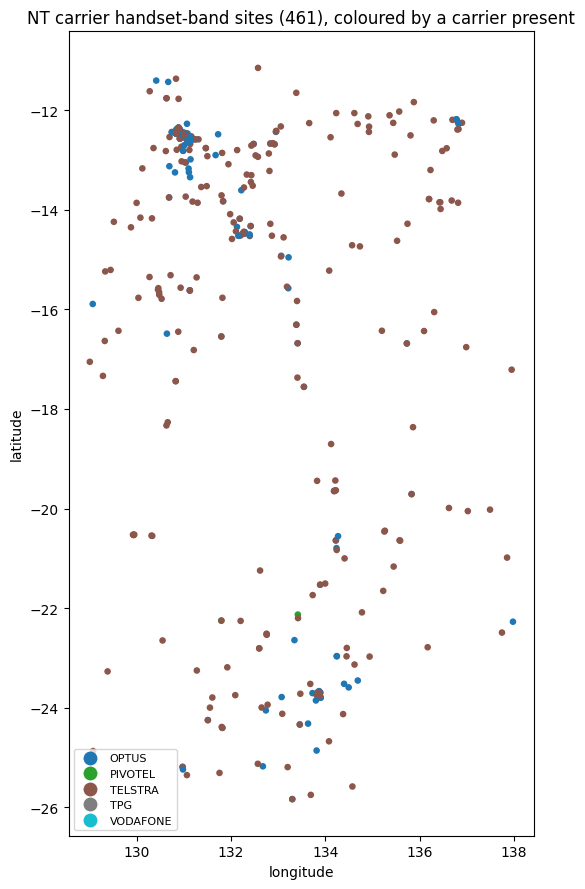

In [10]:
towers_map = (carrier_tx[carrier_tx["handset_band"].isin(HANDSET_BAND_HZ)]
              .groupby("SITE_ID")["carrier"].agg(lambda s: sorted(set(s))[0]))  # first carrier, for colour only
towers_gdf = acma_sites_nt_df[acma_sites_nt_df["SITE_ID"].isin(new_ids)].copy()
towers_gdf["carrier"] = towers_gdf["SITE_ID"].map(towers_map)
towers_gdf = gpd.GeoDataFrame(
    towers_gdf, geometry=gpd.points_from_xy(towers_gdf["lon"], towers_gdf["lat"]), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7.5, 9))
towers_gdf.plot(ax=ax, column="carrier", legend=True, markersize=14, cmap="tab10",
                legend_kwds={"fontsize": 8, "loc": "lower left"})
ax.set_title(f"NT carrier handset-band sites ({len(towers_gdf)}), coloured by a carrier present")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00b_acma_handset_towers_by_carrier_map"] = fig

---
## B. NBN fixed-line and fixed-wireless footprints

A village is "fixed-broadband served" if its point sits inside one of these polygons;
otherwise home internet is Sky Muster satellite. Confirm the attribute schema and see how
far the footprints actually reach.

In [11]:
print("fixed-line : cols =", list(nbn_fixedline_gdf.columns), "| CRS =", nbn_fixedline_gdf.crs)
print("             NT-bbox features =", len(nbn_fixedline_gdf),
      "| geom types =", nbn_fixedline_gdf.geom_type.value_counts().to_dict())
print("             bounds =", [round(x, 2) for x in nbn_fixedline_gdf.total_bounds])
print("\nfixed-wireless: cols =", list(nbn_wireless_gdf.columns), "| CRS =", nbn_wireless_gdf.crs)
print("             NT-bbox features =", len(nbn_wireless_gdf),
      "| geom types =", nbn_wireless_gdf.geom_type.value_counts().to_dict())
print("             bounds =", [round(x, 2) for x in nbn_wireless_gdf.total_bounds])
print("\n-> the ONLY attribute is a polygon id (lower-case `polygon_id` on fixed-line, "
      "capitalised `Polygon_id` on wireless — nb 04 must handle both). No technology/speed "
      "tier field, so nb 04 tags technology from which file the polygon came from.")
print("-> fixed-wireless bounds sit entirely around Darwin/Tiwi; it barely exists in remote NT.")

fixed-line : cols = ['polygon_id', 'geometry'] | CRS = EPSG:4283
             NT-bbox features = 35 | geom types = {'Polygon': 33, 'MultiPolygon': 2}
             bounds = [np.float64(130.81), np.float64(-23.82), np.float64(136.9), np.float64(-12.17)]

fixed-wireless: cols = ['Polygon_id', 'geometry'] | CRS = EPSG:4283
             NT-bbox features = 348 | geom types = {'Polygon': 346, 'MultiPolygon': 2}
             bounds = [np.float64(130.63), np.float64(-12.9), np.float64(131.36), np.float64(-12.31)]

-> the ONLY attribute is a polygon id (lower-case `polygon_id` on fixed-line, capitalised `Polygon_id` on wireless — nb 04 must handle both). No technology/speed tier field, so nb 04 tags technology from which file the polygon came from.
-> fixed-wireless bounds sit entirely around Darwin/Tiwi; it barely exists in remote NT.


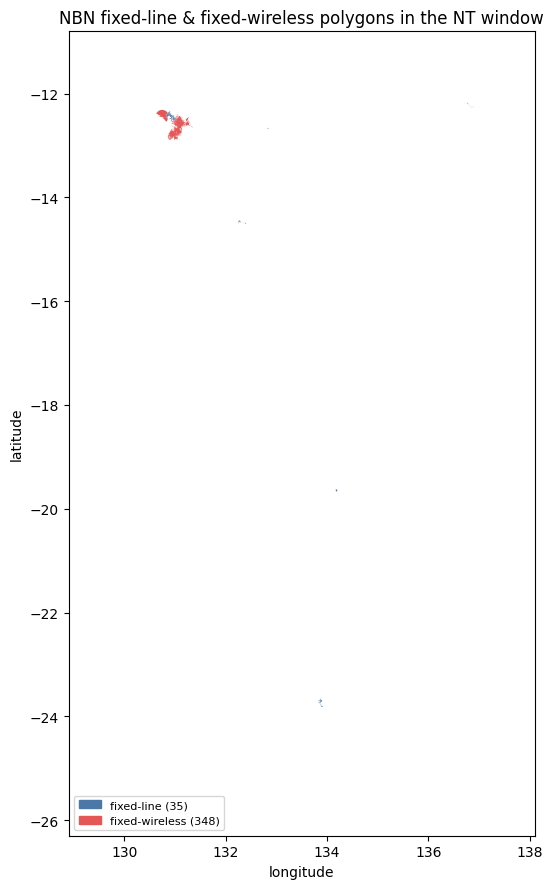

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 9))
nbn_fixedline_gdf.to_crs("EPSG:4326").plot(ax=ax, color="#4c78a8")
nbn_wireless_gdf.to_crs("EPSG:4326").plot(ax=ax, color="#e45756")
ax.set_xlim(NT_BBOX[0], NT_BBOX[2]); ax.set_ylim(NT_BBOX[1], NT_BBOX[3])
ax.legend(handles=[mpatches.Patch(color="#4c78a8", label=f"fixed-line ({len(nbn_fixedline_gdf)})"),
                   mpatches.Patch(color="#e45756", label=f"fixed-wireless ({len(nbn_wireless_gdf)})")],
          fontsize=8, loc="lower left")
ax.set_title("NBN fixed-line & fixed-wireless polygons in the NT window")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00b_nbn_footprint_map"] = fig

---
## C. Mobile Black Spot Program funded base stations (8 KMLs, one per round)

The field schema changes across rounds. Each site is listed twice inside its KML.

In [13]:
mbsp = mbsp_placemarks_df.copy()
print(f"placemarks parsed (all states, both copies): {len(mbsp)}")

# which columns exist in which round
schema = (mbsp.assign(present=1)
          .pivot_table(index="_round", values=[c for c in mbsp.columns if not c.startswith("_")],
                       aggfunc="count", fill_value=0))
print("\nnon-null field counts per round (0 = column absent / always empty):")
print(schema.T.to_string())

placemarks parsed (all states, both copies): 2710

non-null field counts per round (0 = column absent / always empty):
_round                 Round 1  Round 2  Round 3  Round 4  Round 5  Round 5A  Round 6  Round 7
Base_Station_Type          978      524      176      356      338       132       82        0
Completion_Date            974      520      172      326      250        32        0        0
Electorate                   0        0        0        0        0         0       82      124
Electorate_2022            978      524      176      356      338       132        0        0
Grantee                    978      524      176      356      338       132       82      124
Local_Government_Area      978      524      176      356      338       132       82      124
Location                   978      524      176      356      338       132       82        0
MBSP_ID                    978      524      176      356      338       132       82      124
MNHP_funded               

In [14]:
# NT only, dedupe on MBSP_ID (first copy wins)
mbsp_nt = mbsp[mbsp["State"] == "NT"].drop_duplicates("MBSP_ID").copy()
print(f"NT MBSP sites after dedupe on MBSP_ID: {len(mbsp_nt)}")
print("\nper round:")
print(mbsp_nt["_round"].value_counts().sort_index())

# site type: Base_Station_Type (R1-R6) or Solution_type (R7)
mbsp_nt["raw_site_type"] = mbsp_nt["Base_Station_Type"].fillna(mbsp_nt.get("Solution_type"))
print("\nraw site_type spellings (the '5 spellings for 3 things'):")
print(mbsp_nt["raw_site_type"].value_counts(dropna=False))

SITE_TYPE_MAP = {
    "Macro cell": "macro", "Macrocell": "macro",
    "Small cell": "small", "Small Cell": "small",
    "Microcell": "micro",
}
mbsp_nt["site_type_norm"] = mbsp_nt["raw_site_type"].map(SITE_TYPE_MAP)
print("\nnormalised -> macro / small / micro:")
print(mbsp_nt["site_type_norm"].value_counts(dropna=False))
print("(mapping shown above; nb 05 uses SITE_TYPE_MAP)")

mbsp_nt["built"] = mbsp_nt["Site_Status"].str.strip().str.lower().eq("complete")
print("\nSite_Status:", mbsp_nt["Site_Status"].value_counts(dropna=False).to_dict())
print(f"built (Complete): {int(mbsp_nt['built'].sum())}   not yet: {int((~mbsp_nt['built']).sum())}")

NT MBSP sites after dedupe on MBSP_ID: 49

per round:
_round
Round 1     5
Round 2    15
Round 4    12
Round 5    10
Round 7     7
Name: count, dtype: int64

raw site_type spellings (the '5 spellings for 3 things'):
raw_site_type
Small cell    24
Macro cell     9
Small Cell     9
Microcell      5
Macrocell      2
Name: count, dtype: int64

normalised -> macro / small / micro:
site_type_norm
small    33
macro    11
micro     5
Name: count, dtype: int64
(mapping shown above; nb 05 uses SITE_TYPE_MAP)

Site_Status: {'Complete': 41, 'In Progress': 8}
built (Complete): 41   not yet: 8


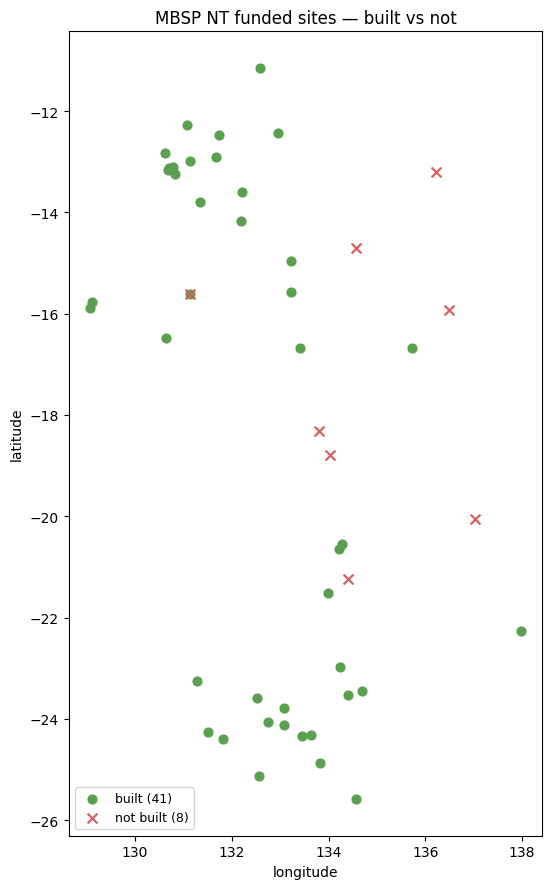

In [15]:
mbsp_gdf = gpd.GeoDataFrame(
    mbsp_nt, geometry=gpd.points_from_xy(mbsp_nt["_lon"], mbsp_nt["_lat"]), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7.5, 9))
mbsp_gdf[mbsp_gdf["built"]].plot(ax=ax, color="#59a14f", markersize=40, label=f"built ({int(mbsp_gdf['built'].sum())})")
mbsp_gdf[~mbsp_gdf["built"]].plot(ax=ax, color="#e45756", marker="x", markersize=50,
                                  label=f"not built ({int((~mbsp_gdf['built']).sum())})")
ax.legend(fontsize=9, loc="lower left")
ax.set_title("MBSP NT funded sites — built vs not")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00b_mbsp_built_unbuilt_map"] = fig

---
## D. NT mobile coverage guide xlsx ("a GUIDE only")

The one source with a named community, a population guess, and an existing macro / small /
proximity read. Header is a few rows down.

In [16]:
header_row = coverage_guide_raw_df.index[
    coverage_guide_raw_df.iloc[:, 0].astype(str).str.strip() == "SITE NAME"][0]
print(f"header row index: {header_row}  (rows 0–{header_row-1} are a banner)")

coverage_guide_df = coverage_guide_raw_df.iloc[header_row + 1:].copy()
coverage_guide_df.columns = [str(c).strip() for c in coverage_guide_raw_df.iloc[header_row]]
coverage_guide_df = coverage_guide_df.dropna(how="all")
for col in ("MACRO CELL", "SMALL CELL", "PROXIMITY TO CELL"):
    coverage_guide_df[col] = coverage_guide_df[col].astype(str).str.strip().str.upper().eq("YES")
coverage_guide_df["lat"] = pd.to_numeric(coverage_guide_df["LATITUDE"], errors="coerce")
coverage_guide_df["lon"] = pd.to_numeric(coverage_guide_df["LONGITUDE"], errors="coerce")

print(f"\ndata rows: {len(coverage_guide_df)}  |  missing lat/lon: "
      f"{int(coverage_guide_df[['lat','lon']].isna().any(axis=1).sum())}")
print("\nSITE TYPE:")
print(coverage_guide_df["SITE TYPE"].astype(str).str.strip().value_counts())
print("\nPROVIDER:")
print(coverage_guide_df["PROVIDER"].astype(str).str.strip().value_counts())
print("\nPOPULATION (reference only, never used as population): "
      f"{pd.to_numeric(coverage_guide_df['POPULATION'], errors='coerce').notna().sum()} rows have a figure")

header row index: 4  (rows 0–3 are a banner)

data rows: 188  |  missing lat/lon: 0

SITE TYPE:
SITE TYPE
COMMUNITY    148
HIGHWAY       17
TOURISM       15
VILLAGE        8
Name: count, dtype: int64

PROVIDER:
PROVIDER
TELSTRA          134
OPTUS/TELSTRA     40
OPTUS             14
Name: count, dtype: int64

POPULATION (reference only, never used as population): 155 rows have a figure


In [17]:
print("MACRO x SMALL x PROXIMITY — how the three flags combine:")
combo = (coverage_guide_df.groupby(["MACRO CELL", "SMALL CELL", "PROXIMITY TO CELL"])
         .size().rename("rows").reset_index())
print(combo.to_string(index=False))
print("\n-> every row has at least one flag set; 96 rows are 'PROXIMITY only' "
      "(no macro, no small of their own).")

MACRO x SMALL x PROXIMITY — how the three flags combine:
 MACRO CELL  SMALL CELL  PROXIMITY TO CELL  rows
      False       False               True    96
      False        True              False    29
      False        True               True     1
       True       False              False    56
       True       False               True     1
       True        True              False     5

-> every row has at least one flag set; 96 rows are 'PROXIMITY only' (no macro, no small of their own).


### D.1 The contradiction: `PROXIMITY = YES` but no real tower nearby

"Proximity to cell" means close enough to a macro cell elsewhere to get coverage without
its own site. Test that against the NEW handset-tower set from section A — straight-line,
triage only.

In [18]:
towers_3577 = gpd.GeoDataFrame(
    towers_gdf[["SITE_ID"]], geometry=towers_gdf.geometry, crs="EPSG:4326").to_crs("EPSG:3577")

guide_geo = gpd.GeoDataFrame(
    coverage_guide_df.dropna(subset=["lat", "lon"]).copy(),
    geometry=gpd.points_from_xy(coverage_guide_df.dropna(subset=["lat", "lon"])["lon"],
                                coverage_guide_df.dropna(subset=["lat", "lon"])["lat"]),
    crs="EPSG:4326").to_crs("EPSG:3577")

guide_geo = gpd.sjoin_nearest(guide_geo, towers_3577, how="left", distance_col="m").drop(columns="index_right")
guide_geo["km_nearest_tower"] = guide_geo["m"] / 1000

proximity_only = guide_geo[guide_geo["PROXIMITY TO CELL"]
                           & ~guide_geo["MACRO CELL"] & ~guide_geo["SMALL CELL"]]
print(f"'PROXIMITY only' rows: {len(proximity_only)}")
for thr in (5, 10, 15, 30):
    print(f"  nearest handset tower > {thr:>2} km: {int((proximity_only['km_nearest_tower'] > thr).sum())}")
print("\nfarthest 12:")
print(proximity_only.sort_values("km_nearest_tower", ascending=False)
      [["SITE NAME", "km_nearest_tower"]].head(12).to_string(index=False))
print("\n-> the guide says these get coverage 'by proximity', but the nearest licensed "
      "handset transmitter is 15–43 km away. nb 06 keeps guide flags as the guide's claim "
      "and flags `guide_proximity_only` separately from the measured distance.")

'PROXIMITY only' rows: 96
  nearest handset tower >  5 km: 55
  nearest handset tower > 10 km: 28
  nearest handset tower > 15 km: 10
  nearest handset tower > 30 km: 2

farthest 12:
      SITE NAME  km_nearest_tower
          WILGI         42.425683
 MANDEDJKADJANG         31.357499
            KUY         23.956511
  UNDOOLYA BORE         22.636265
  DHIPIRRINJURA         20.866728
       MUMUKALA         19.676600
AILERON STATION         19.112533
      BUNHANURA         16.724431
        NTURIYA         15.562062
    LIZARD BORE         15.343420
    ITEYEPINTYE         13.929040
        ELITJIA         13.596523

-> the guide says these get coverage 'by proximity', but the nearest licensed handset transmitter is 15–43 km away. nb 06 keeps guide flags as the guide's claim and flags `guide_proximity_only` separately from the measured distance.


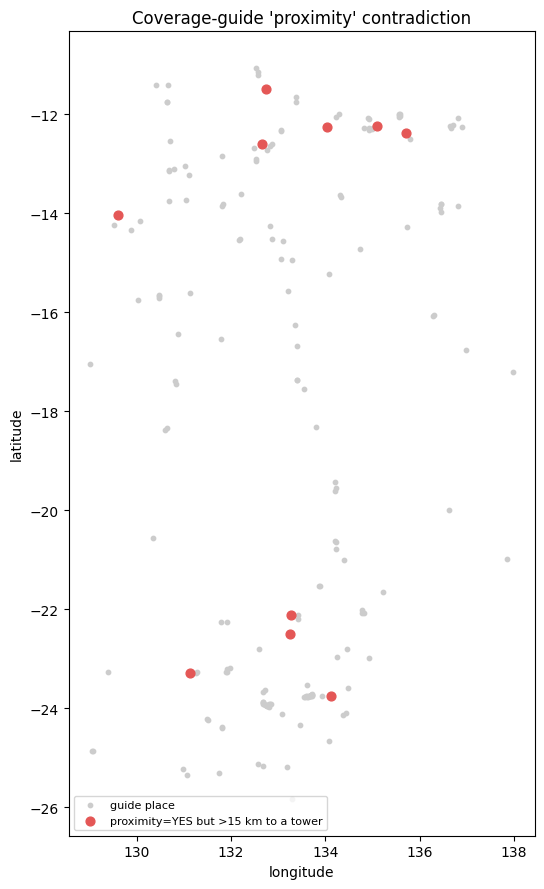

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 9))
guide_geo.to_crs("EPSG:4326").plot(ax=ax, color="0.8", markersize=10, label="guide place")
far = proximity_only[proximity_only["km_nearest_tower"] > 15].to_crs("EPSG:4326")
far.plot(ax=ax, color="#e45756", markersize=40, label="proximity=YES but >15 km to a tower")
ax.legend(fontsize=8, loc="lower left")
ax.set_title("Coverage-guide 'proximity' contradiction")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00b_guide_proximity_contradiction_map"] = fig

---
## E. RICT community-phone list — every key and code, then the decision

Dump every property key and every `site_type` value. The decision on what to keep (it was
made after this section was first written) is in the box below the code.

In [20]:
print("EVERY property key on the RICT features:")
for k in rict_communities_df.columns:
    print(f"  {k!r:40s} non-null {rict_communities_df[k].notna().sum()}")

print("\nstate value counts (raw):")
print(rict_communities_df["state"].value_counts(dropna=False))
print("(one row has state 'a' — its coordinates fall in WA; excluded by the NT filter.)")

rict_nt = rict_communities_df[rict_communities_df["state"] == "NT"]
print(f"\nNT RICT rows: {len(rict_nt)}   distinct community_name: {rict_nt['community_name'].nunique()} "
      f"({int(rict_nt['community_name'].duplicated().sum())} communities have >1 site)")

print("\nsite_type value counts (NT):")
print(rict_nt["site_type"].value_counts(dropna=False))
print("\n-> 4 codes: WP, CP, CPW, WH. Meanings (NIAA RICT program): CP community phone, WP Wi-Fi phone, CPW community phone + Wi-Fi, WH Wi-Fi hotspot. "
      "There are NO other service-indicator fields — `site_type` is the only signal, and "
      "`alternative_community_name___lo` is a free-text location description, not an alias.")

print("\nsample NT rows:")
print(rict_nt[["community_name", "alternative_community_name___lo", "site_type",
               "latitude", "longitude"]].head(8).to_string(index=False))

EVERY property key on the RICT features:
  'site_type'                              non-null 535
  'community_name'                         non-null 535
  'latitude'                               non-null 535
  'alternative_community_name___lo'        non-null 466
  'state'                                  non-null 535
  'objectid'                               non-null 535
  'longitude'                              non-null 535

state value counts (raw):
state
NT     296
WA     148
QLD     61
SA      29
a        1
Name: count, dtype: int64
(one row has state 'a' — its coordinates fall in WA; excluded by the NT filter.)

NT RICT rows: 296   distinct community_name: 258 (38 communities have >1 site)

site_type value counts (NT):
site_type
WP     154
CP     106
CPW     23
WH      13
Name: count, dtype: int64

-> 4 codes: WP, CP, CPW, WH. Meanings (NIAA RICT program): CP community phone, WP Wi-Fi phone, CPW community phone + Wi-Fi, WH Wi-Fi hotspot. There are NO other service-indicator fi

> **DECISION (2026-09-06) — RICT is in, as a proximity match.**
>
> **a. All four `site_type` codes count as public access** — the program is public phones
>    and Wi-Fi by definition. `has_rict_public_access` (nb 06) = *any* RICT site within
>    **`RICT_MATCH_KM`** of the village (constant, default **2 km**, same cutoff as the
>    coverage-guide name match).
> **b. Also carry** `rict_site_type` (the raw code; if a village matches >1 RICT site, join
>    the codes with `";"`) and `n_rict_sites` (count within `RICT_MATCH_KM`).
> **c. Multi-site communities:** nothing special beyond `n_rict_sites`.
> **d. Validation (nb 06):** histogram of village → nearest-RICT distance; map of RICT
>    sites that matched no village.
>
> **Code meanings (NIAA RICT program):** `CP` community phone · `WP` Wi-Fi phone · `CPW` community phone + Wi-Fi · `WH` Wi-Fi hotspot.
> The pipeline carries the raw code in `rict_site_type`.


---
## F. Overlay — everything on one NT map

ACMA handset towers, MBSP built / not built, coverage-guide places. Different colours, one
picture of where the infrastructure actually is.

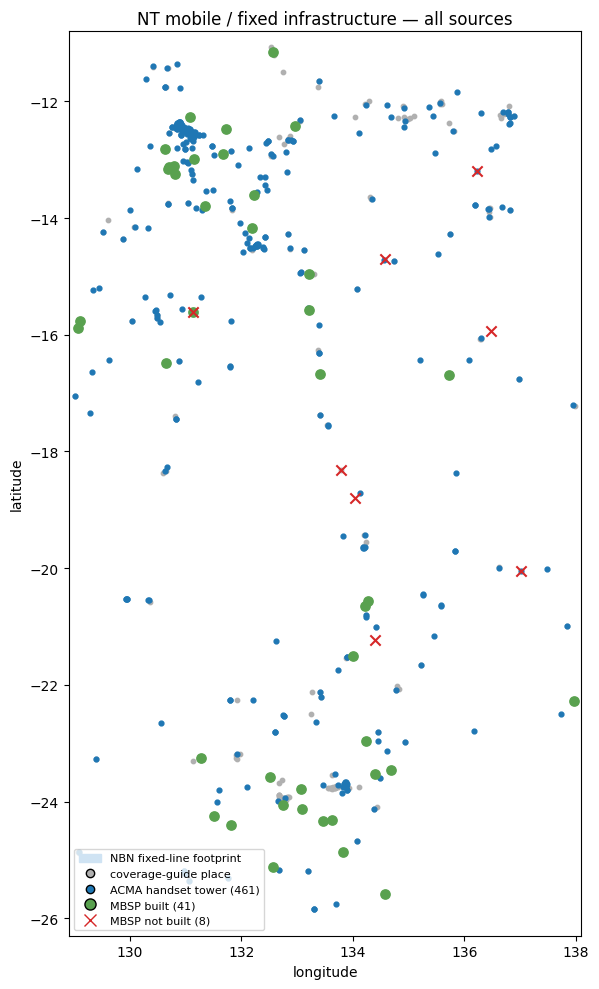

In [21]:
n_built = int(mbsp_gdf["built"].sum()); n_unbuilt = int((~mbsp_gdf["built"]).sum())
fig, ax = plt.subplots(figsize=(8.5, 10))
nbn_fixedline_gdf.to_crs("EPSG:4326").plot(ax=ax, color="#cfe3f3", edgecolor="none")
guide_geo.to_crs("EPSG:4326").plot(ax=ax, color="#b0b0b0", markersize=10)
towers_gdf.plot(ax=ax, color="#1f77b4", markersize=12)
mbsp_gdf[mbsp_gdf["built"]].plot(ax=ax, color="#59a14f", markersize=45)
mbsp_gdf[~mbsp_gdf["built"]].plot(ax=ax, color="#d62728", marker="x", markersize=55)
ax.set_xlim(NT_BBOX[0], NT_BBOX[2]); ax.set_ylim(NT_BBOX[1], NT_BBOX[3])
ax.legend(handles=[
    mpatches.Patch(color="#cfe3f3", label="NBN fixed-line footprint"),
    Line2D([], [], marker="o", color="none", markerfacecolor="#b0b0b0", markersize=6, label="coverage-guide place"),
    Line2D([], [], marker="o", color="none", markerfacecolor="#1f77b4", markersize=6, label=f"ACMA handset tower ({len(towers_gdf)})"),
    Line2D([], [], marker="o", color="none", markerfacecolor="#59a14f", markersize=8, label=f"MBSP built ({n_built})"),
    Line2D([], [], marker="x", color="#d62728", linestyle="none", markersize=8, label=f"MBSP not built ({n_unbuilt})"),
], fontsize=8, loc="lower left")
ax.set_title("NT mobile / fixed infrastructure — all sources")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.tight_layout()
eda_figures["00b_overlay_map"] = fig

---
## G. Data-quality list — what notebooks 03–06 must do

| # | issue found in this notebook | what the pipeline does about it |
|---|---|---|
| 1 | ACMA `FREQUENCY` and `BANDWIDTH` are in **plain Hz**; `EIRP` / `TRANSMITTER_POWER` in **watts**. | nb 03 defines handset bands in Hz; `spectrum_depth_khz = sum(BANDWIDTH)/1000`; `max_eirp` kept in W (note the unit in the column doc). |
| 2 | `DEVICE_TYPE` on NT sites is only **`T` / `R`** (transmitter / receiver). | nb 03 keeps `DEVICE_TYPE == 'T'`; adds a `handset_band` bool so nothing is dropped silently. |
| 3 | Most carrier-held licences are **`Point to Point`** (backhaul) etc., not mobile spectrum. Selecting sites by carrier alone would pull in microwave links. | nb 03 requires a carrier transmitter **in a handset frequency band**, not just a carrier licence at the site. |
| 4 | Old 16-category `LICENCE_CATEGORY_NAME` method = **458** NT sites (reproduced exactly). New frequency method = **461**. The switch barely changes the *set* — **453 kept by both, 5 dropped (2.5 GHz-only), 8 added** — because nearly every capacity/mmWave site is co-located with a handset-band transmitter on the same tower. It mainly makes the *reason* a site qualifies defensible. | nb 03 filters by carrier + `DEVICE_TYPE=='T'` + handset frequency; documents the funnel and the 5 dropped / 8 added. |
| 5 | **958 / 3,771** NT ACMA sites have another site within 100 m (270 within 25 m); **151 of the 461** handset towers do — heavy co-location. | **Decision:** **nb 03** clusters handset sites within **100 m** into one `towers.csv` row — `carriers` unioned, `spectrum_depth_khz` summed, `n_carriers`/`n_transmitters` recomputed, new **`n_colocated`** = sites merged. nb 03 shows the before/after site count and a map of the clusters. nb 06 then measures distance to the already-deduped set. |
| 6 | ACMA `SITE_PRECISION`: ~1,450 "Unknown", ~480 "Within 100 metres". | Straight-line triage only; stated in the markdown above every distance step (PROJECT_CONTEXT §5). |
| 7 | NBN shapefiles carry **only a polygon id** — `polygon_id` (fixed-line) vs `Polygon_id` (wireless), different case. No technology field. | nb 04 reads each file separately, sets `technology` from the source file, handles both column spellings, dissolves per technology. |
| 8 | NBN **fixed-wireless** polygons sit entirely around Darwin / Tiwi; **fixed-line** is ~35 town footprints. Remote communities are almost all outside both. | nb 06 `in_nbn_fixed_line` / `in_nbn_fixed_wireless` will be `False` for most villages — expected, not a bug; the report says remote = Sky Muster satellite. |
| 9 | MBSP `site_type` has **5 spellings for 3 things** — `Macro cell`/`Macrocell` → macro, `Small cell`/`Small Cell` → small, `Microcell` → micro. R7 uses `Solution_type`/`Solution_name` instead of `Base_Station_Type`/`Location`; R1–R2 have `MNHP_funded`; R6–R7 rename `Electorate_2022` → `Electorate`. | nb 05 uses `SITE_TYPE_MAP`, falls back `Base_Station_Type` → `Solution_type` and `Location` → `Solution_name`, dedupes on `MBSP_ID`. |
| 10 | MBSP NT: **49** sites after dedupe (R1 5, R2 15, R4 12, R5 10, R7 7; R3/R5A/R6 none). `Site_Status` ∈ {Complete, In Progress} → **41 built / 8 not**. | nb 05: `mbsp_built = Site_Status == 'Complete'`, `mbsp_round` kept; nb 06 splits nearest-built vs nearest-unbuilt. |
| 11 | Coverage guide: header at **row index 4**; 188 rows; `SITE TYPE` = COMMUNITY 148 / HIGHWAY 17 / TOURISM 15 / VILLAGE 8; every row has ≥1 of MACRO/SMALL/PROXIMITY. | nb 05 finds the header by searching for "SITE NAME"; keeps HIGHWAY/TOURISM tagged but out of community rankings (PROJECT_CONTEXT §2.8). |
| 12 | **Proximity contradiction:** 96 rows are `PROXIMITY`-only; **10 of them are >15 km** from the nearest handset tower (2 are >30 km: WILGI 43 km, MANDEDJKADJANG 32 km). Guide and ACMA disagree. | nb 06 keeps `guide_says_covered` (guide's claim) and `guide_proximity_only` **separate** from measured `km_nearest_tower`; `distance_gap_candidate` ignores proximity. |
| 13 | Coverage-guide `POPULATION` — 155 rows, sums to ~30k. | Reference only, never used as population (PROJECT_CONTEXT §2). Carried as `guide_population`. |
| 14 | **RICT codes.** NT: 296 sites, 258 communities; `site_type` ∈ {WP 154, CP 106, CPW 23, WH 13}; no other service field; alt-name is a location description. | **Decision (section E):** all 4 codes = public access. nb 06 → `has_rict_public_access` = any RICT site within `RICT_MATCH_KM` (2 km); also `rict_site_type` (raw codes, `;`-joined) and `n_rict_sites`. Meanings: CP community phone, WP Wi-Fi phone, CPW community phone + Wi-Fi, WH Wi-Fi hotspot. nb 06 validates with a distance histogram + a map of unmatched RICT sites. |
| 15 | STAND | Not read. Dropped from the pipeline — no unique signal. |

### Guards

In [22]:
assert len(acma_sites_nt_df) == 3771, "expected 3,771 NT ACMA sites"
assert set(acma_devices_nt_df["DEVICE_TYPE"].dropna().unique()) <= {"T", "R"}, "unexpected DEVICE_TYPE code"
assert len(old_ids) == 458, f"old 16-category method should reproduce 458, got {len(old_ids)}"
assert len(mbsp_nt) == 49, f"expected 49 NT MBSP sites, got {len(mbsp_nt)}"
assert int(mbsp_nt['built'].sum()) == 41, "expected 41 built MBSP sites"
assert len(coverage_guide_df) == 188, f"expected 188 coverage-guide rows, got {len(coverage_guide_df)}"
assert set(rict_nt["site_type"].unique()) == {"WP", "CP", "CPW", "WH"}, "unexpected RICT site_type"
ASSERTS_PASSED = 7
print(f"{ASSERTS_PASSED} guards passed")

7 guards passed


In [23]:
print("00b EDA - summary")
print("-" * 62)
print(f"ACMA          : 3,771 NT sites; {carrier_tx['SITE_ID'].nunique()} with a carrier tx; "
      f"{len(new_ids)} with a carrier handset-band tx (old method: {len(old_ids)})")
print(f"co-location   : {int((nearest_m < 100).sum())} NT sites have a neighbour within 100 m")
print(f"NBN           : fixed-line {len(nbn_fixedline_gdf)} polys (towns), fixed-wireless "
      f"{len(nbn_wireless_gdf)} polys (Darwin/Tiwi only)")
print(f"MBSP          : 49 NT sites, 41 built / 8 not; 5 site_type spellings -> macro/small/micro")
print(f"coverage guide: 188 rows; 96 'proximity only'; "
      f"{int((proximity_only['km_nearest_tower'] > 15).sum())} of those >15 km from a real tower")
print(f"RICT          : 296 NT sites, 4 site_type codes - all count as public access; "
      f"nb 06 matches within RICT_MATCH_KM (2 km)")
print("dropped       : nothing (read-only EDA); STAND not read")
print(f"asserts       : {ASSERTS_PASSED} passed")
print(f"plots         : {len(eda_figures)} figures queued for docs/eda/")

00b EDA - summary
--------------------------------------------------------------
ACMA          : 3,771 NT sites; 753 with a carrier tx; 461 with a carrier handset-band tx (old method: 458)
co-location   : 958 NT sites have a neighbour within 100 m
NBN           : fixed-line 35 polys (towns), fixed-wireless 348 polys (Darwin/Tiwi only)
MBSP          : 49 NT sites, 41 built / 8 not; 5 site_type spellings -> macro/small/micro
coverage guide: 188 rows; 96 'proximity only'; 10 of those >15 km from a real tower
RICT          : 296 NT sites, 4 site_type codes - all count as public access; nb 06 matches within RICT_MATCH_KM (2 km)
dropped       : nothing (read-only EDA); STAND not read
asserts       : 7 passed
plots         : 6 figures queued for docs/eda/


In [24]:
# Last cell: the only writes — PNGs to docs/eda/.
for name, fig in eda_figures.items():
    path = EDA_PLOT_DIR / f"{name}.png"
    fig.savefig(path, dpi=120, bbox_inches="tight")
    print("wrote", path)

wrote docs\eda\00b_acma_frequency_bandwidth_hist.png


wrote docs\eda\00b_acma_handset_towers_by_carrier_map.png
wrote docs\eda\00b_nbn_footprint_map.png


wrote docs\eda\00b_mbsp_built_unbuilt_map.png


wrote docs\eda\00b_guide_proximity_contradiction_map.png
wrote docs\eda\00b_overlay_map.png
